In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score



In [2]:
import seaborn as sns
titanic = sns.load_dataset('titanic')

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df = titanic[['survived','pclass','sex','age','sibsp','parch','fare','embarked']].dropna()

df['sex'] = df['sex'].astype('category').cat.codes
df['embarked'] = df['embarked'].astype('category').cat.codes

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X.head()


,pclass,sex,age,sibsp,parch,fare,embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


In [4]:


tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_tree))
print(confusion_matrix(y_test, pred_tree))

Accuracy: 0.7062937062937062
[[63 17]
 [25 38]]


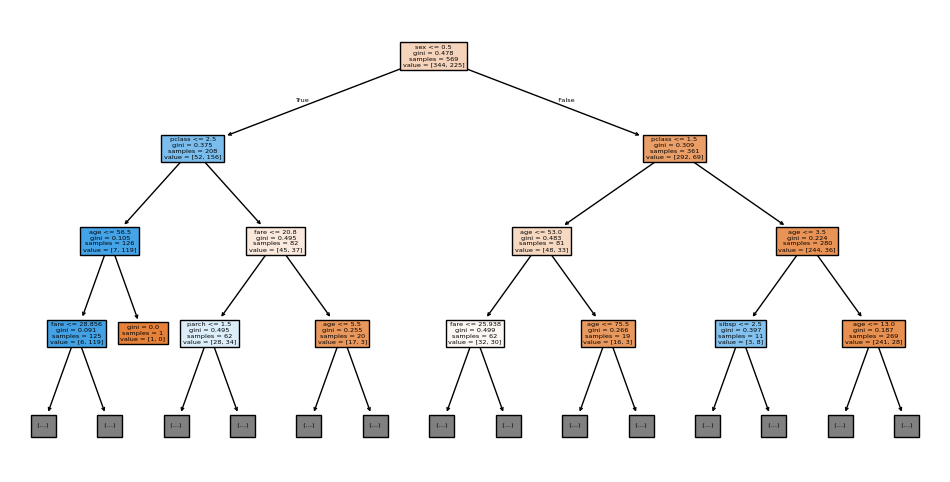

In [5]:
plt.figure(figsize=(12,6))
plot_tree(tree, feature_names=X.columns, filled=True, max_depth=3)
plt.show()


In [6]:
tree_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_pruned.fit(X_train, y_train)

pred_pruned = tree_pruned.predict(X_test)

print("Accuracy (pruned):", accuracy_score(y_test, pred_pruned))


Accuracy (pruned): 0.7482517482517482


In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))


Accuracy: 0.7902097902097902


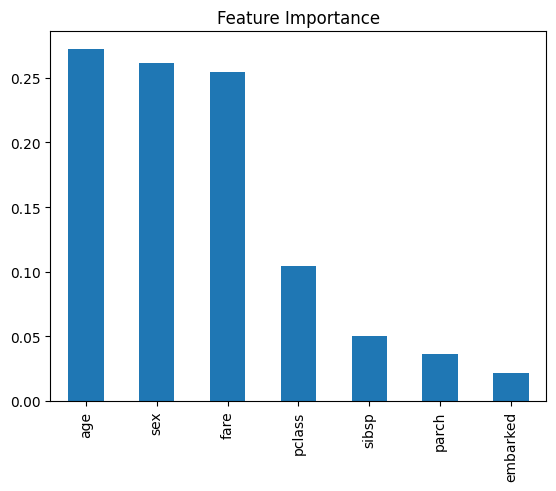

In [8]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()


In [9]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82        80
           1       0.78      0.73      0.75        63

    accuracy                           0.79       143
   macro avg       0.79      0.78      0.79       143
weighted avg       0.79      0.79      0.79       143

